# 06 - Race analysis and training context


# Common setup

These notebooks assume a local project structure like:

```text
project/
  data/
    workouts.csv
    samples.csv              # optional
    intervals.csv            # optional
    race_results.csv          # optional
```

The exact iOS export format may vary. The helper functions below try to standardize common column names. If your export uses different names, edit the `COLUMN_ALIASES` dictionary.

The notebooks also include a small synthetic-data fallback. That lets the notebook run even before real Apple Watch / iOS CSV files are placed in `data/`.

**Expected output:** The cell should run without errors and make the required packages, paths, or helper tools available for the rest of the notebook.


In [1]:
from pathlib import Path
import math
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = PROCESSED_DIR

workout_path = PROCESSED_DIR / "clean_workouts.csv"
race_path = PROCESSED_DIR / "clean_race_results.csv"

if not workout_path.exists():
    raise FileNotFoundError("Run 01_swim_data_ingestion_and_cleaning.ipynb first.")
if not race_path.exists():
    raise FileNotFoundError("Run 02_race_data_ingestion_and_cleaning.ipynb first.")

workouts = pd.read_csv(workout_path)
races = pd.read_csv(race_path)
workouts["date"] = pd.to_datetime(workouts["date"], errors="coerce", utc=True).dt.tz_convert(None)
workouts["week_start"] = pd.to_datetime(workouts["week_start"], errors="coerce", utc=True).dt.tz_convert(None)
races["race_date"] = pd.to_datetime(races["race_date"], errors="coerce", utc=True).dt.tz_convert(None)
races = races.rename(columns={"meet": "meet_name", "course": "pool_course"})

print("Loaded prepared workouts:", len(workouts))
print("Loaded prepared race results:", len(races))
display(races.head(3))
display(races.tail(3))


Loaded prepared workouts: 452
Loaded prepared race results: 453


,swimmer,event,pool_course,time,time_seconds,date,meet_name,age,points,team,...,race_time,race_time_sec,distance,stroke,raw_record,event_course,event_best_sec,is_best_time,percent_off_best,is_current_year
0,gmo,50 FR SCY,SCY,38.37,38.37,2018-09-16,2018 PC SSF C/B/A+,9,280.0,San Francisco Serpents,...,38.37,38.37,50.0,freestyle,"{'Age': '9', 'Event': '50 FR SCY', 'LSC': 'PC'...",50 FR SCY SCY,27.65,False,38.770344,False
1,gmo,50 BR SCY,SCY,50.68,50.68,2019-02-23,2019 PC VJO C/B/A+,9,274.0,San Francisco Serpents,...,50.68,50.68,50.0,breaststroke,"{'Age': '9', 'Event': '50 BR SCY', 'LSC': 'PC'...",50 BR SCY SCY,41.44,False,22.297297,False
2,gmo,100 BK SCY,SCY,1:31.58,91.58,2019-02-23,2019 PC VJO C/B/A+,9,375.0,San Francisco Serpents,...,1:31.58,91.58,100.0,backstroke,"{'Age': '9', 'Event': '100 BK SCY', 'LSC': 'PC...",100 BK SCY SCY,69.09,False,32.551744,False


,swimmer,event,pool_course,time,time_seconds,date,meet_name,age,points,team,...,race_time,race_time_sec,distance,stroke,raw_record,event_course,event_best_sec,is_best_time,percent_off_best,is_current_year
450,gmo,200 FR SCY,SCY,2:08.12,128.12,2026-05-09,2026 SN Post High School Meet,16,404.0,California Capital Aquatics,...,2:08.12,128.12,200.0,freestyle,"{'Age': '16', 'Event': '200 FR SCY', 'LSC': 'S...",200 FR SCY SCY,124.66,False,2.775549,True
451,gmo,50 FR SCY,SCY,27.67,27.67,2026-05-09,2026 SN Post High School Meet,16,452.0,California Capital Aquatics,...,27.67,27.67,50.0,freestyle,"{'Age': '16', 'Event': '50 FR SCY', 'LSC': 'SN...",50 FR SCY SCY,27.65,False,0.072333,True
452,gmo,200 BK SCY,SCY,2:27.04,147.04,2026-05-09,2026 SN Post High School Meet,16,408.0,California Capital Aquatics,...,2:27.04,147.04,200.0,backstroke,"{'Age': '16', 'Event': '200 BK SCY', 'LSC': 'S...",200 BK SCY SCY,143.56,False,2.424074,True


## Why use lookback windows?

For each race, summarize the training completed before that race. A 7-day window captures short-term readiness or taper. A 28-day window captures the recent training block.

A lookback training subset is:

$$
\text{training window} = \{w : \text{race date} - d \le \text{workout date} < \text{race date}\}
$$

Code-style implementation:

```python
subset = workouts[(workouts["date"] < race_date) & (workouts["date"] >= race_date - pd.Timedelta(days=days))]
```

Window volume is:

$$
\text{volume}_{d} = \sum \text{distance}_m
$$

Code-style implementation:

```python
f"volume_{days}d": subset["distance_m"].sum()
```

**Expected output:** The cell should define reusable helper logic. The main thing to interpret is that later cells can call the function consistently.


In [2]:
def summarize_training_before_race(workouts, race_date, days):
    start = race_date - pd.Timedelta(days=days)
    subset = workouts[(workouts["date"] < race_date) & (workouts["date"] >= start)].copy()
    if subset.empty:
        return {
            f"sessions_{days}d": 0,
            f"volume_{days}d": 0,
            f"avg_pace_{days}d": np.nan,
            f"best_pace_{days}d": np.nan,
            f"avg_hr_{days}d": np.nan,
            f"avg_distance_per_stroke_{days}d": np.nan,
            f"avg_swolf_{days}d": np.nan,
        }
    return {
        f"sessions_{days}d": len(subset),
        f"volume_{days}d": subset["distance_m"].sum(),
        f"avg_pace_{days}d": subset["pace_sec_per_100m"].mean(),
        f"best_pace_{days}d": subset["pace_sec_per_100m"].min(),
        f"avg_hr_{days}d": subset["avg_hr"].mean() if "avg_hr" in subset else np.nan,
        f"avg_distance_per_stroke_{days}d": subset["distance_per_stroke_m"].mean() if "distance_per_stroke_m" in subset else np.nan,
        f"avg_swolf_{days}d": subset["swolf"].mean() if "swolf" in subset else np.nan,
    }

race_features = []
for _, race in races.iterrows():
    row = race.to_dict()
    for days in [7, 14, 28, 56]:
        row.update(summarize_training_before_race(workouts, race["race_date"], days))
    row["volume_drop_ratio"] = row["volume_7d"] / (row["volume_28d"] / 4) if row["volume_28d"] else np.nan
    race_features.append(row)

race_df = pd.DataFrame(race_features)
display(race_df.head(3))
display(race_df.tail(3))

,swimmer,event,pool_course,time,time_seconds,date,meet_name,age,points,team,...,avg_distance_per_stroke_28d,avg_swolf_28d,sessions_56d,volume_56d,avg_pace_56d,best_pace_56d,avg_hr_56d,avg_distance_per_stroke_56d,avg_swolf_56d,volume_drop_ratio
0,gmo,50 FR SCY,SCY,38.37,38.37,2018-09-16,2018 PC SSF C/B/A+,9,280.0,San Francisco Serpents,...,NaN,NaN,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,gmo,50 BR SCY,SCY,50.68,50.68,2019-02-23,2019 PC VJO C/B/A+,9,274.0,San Francisco Serpents,...,NaN,NaN,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,gmo,100 BK SCY,SCY,1:31.58,91.58,2019-02-23,2019 PC VJO C/B/A+,9,375.0,San Francisco Serpents,...,NaN,NaN,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN


,swimmer,event,pool_course,time,time_seconds,date,meet_name,age,points,team,...,avg_distance_per_stroke_28d,avg_swolf_28d,sessions_56d,volume_56d,avg_pace_56d,best_pace_56d,avg_hr_56d,avg_distance_per_stroke_56d,avg_swolf_56d,volume_drop_ratio
450,gmo,200 FR SCY,SCY,2:08.12,128.12,2026-05-09,2026 SN Post High School Meet,16,404.0,California Capital Aquatics,...,3.184044,NaN,36,103691.481842,109.644137,42.436144,NaN,3.12401,NaN,0.742019
451,gmo,50 FR SCY,SCY,27.67,27.67,2026-05-09,2026 SN Post High School Meet,16,452.0,California Capital Aquatics,...,3.184044,NaN,36,103691.481842,109.644137,42.436144,NaN,3.12401,NaN,0.742019
452,gmo,200 BK SCY,SCY,2:27.04,147.04,2026-05-09,2026 SN Post High School Meet,16,408.0,California Capital Aquatics,...,3.184044,NaN,36,103691.481842,109.644137,42.436144,NaN,3.12401,NaN,0.742019


## Normalize race performance across events

Raw race times should not be mixed across events. A 50 free time and a 500 free time have different scales.

Within each event:

$$
\text{event best} = \min(\text{race time seconds})
$$

Code-style implementation:

```python
race_df["event_best_sec"] = race_df.groupby("event")["race_time_sec"].transform("min")
```

Then calculate percent off best:

$$
\text{percent off best} = \frac{\text{race time} - \text{event best}}{\text{event best}} \times 100
$$

Code-style implementation:

```python
race_df["percent_off_best"] = (race_df["race_time_sec"] - race_df["event_best_sec"]) / race_df["event_best_sec"] * 100
```

**Expected output:** Expect paired previews: the first 3 rows show the starting structure, and the latest 3 rows help confirm the most recent records look reasonable.


In [3]:
race_df["event_best_sec"] = race_df.groupby("event")["race_time_sec"].transform("min")
race_df["percent_off_best"] = (race_df["race_time_sec"] - race_df["event_best_sec"]) / race_df["event_best_sec"] * 100

display(race_df[["race_date", "event", "race_time_sec", "event_best_sec", "percent_off_best"]].head(3))
display(race_df[["race_date", "event", "race_time_sec", "event_best_sec", "percent_off_best"]].tail(3))

,race_date,event,race_time_sec,event_best_sec,percent_off_best
0,2018-09-16,50 FR SCY,38.37,27.65,38.770344
1,2019-02-23,50 BR SCY,50.68,41.44,22.297297
2,2019-02-23,100 BK SCY,91.58,69.09,32.551744


,race_date,event,race_time_sec,event_best_sec,percent_off_best
450,2026-05-09,200 FR SCY,128.12,124.66,2.775549
451,2026-05-09,50 FR SCY,27.67,27.65,0.072333
452,2026-05-09,200 BK SCY,147.04,143.56,2.424074


## Race timeline with training context

This chart overlays weekly training volume and race dates. It is useful for identifying heavy blocks, taper weeks, and clusters of races.

**Expected output:** The cell should run without errors and make the required packages, paths, or helper tools available for the rest of the notebook.


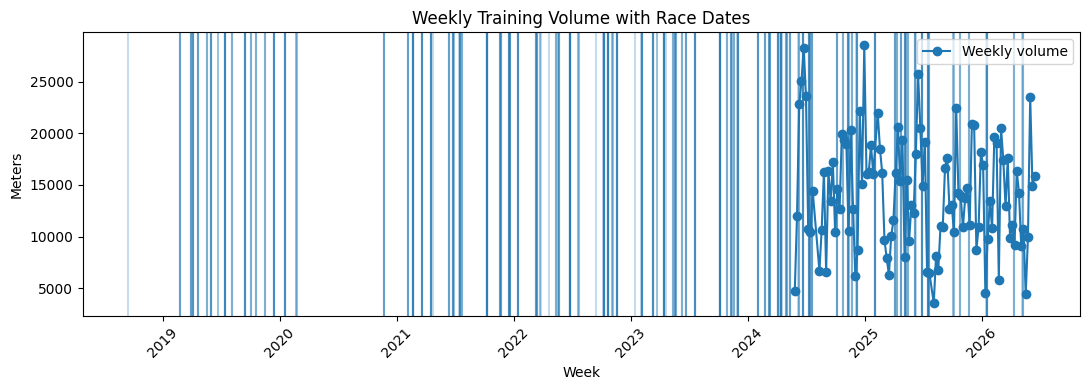

In [4]:
weekly_for_plot = workouts.groupby("week_start").agg(total_distance_m=("distance_m", "sum")).reset_index()

import matplotlib.pyplot as plt

plt.figure(figsize=(11, 4))
plt.plot(weekly_for_plot["week_start"], weekly_for_plot["total_distance_m"], marker="o", label="Weekly volume")
for _, r in race_df.iterrows():
    plt.axvline(r["race_date"], alpha=0.25)
plt.title("Weekly Training Volume with Race Dates")
plt.xlabel("Week")
plt.ylabel("Meters")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Correlation table

Correlation measures linear association:

$$
r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{(n - 1)s_xs_y}
$$

Code-style implementation:

```python
corr = valid[p].corr(valid["percent_off_best"])
```

Important interpretation rule: if the response is `race_time_sec` or `percent_off_best`, lower is better. A positive correlation means larger predictor values are associated with slower relative race performance.

**Expected output:** Expect relationship measures between variables. Interpret direction and strength, but remember correlation does not prove causation.


In [5]:
predictors = [
    "sessions_7d", "volume_7d", "avg_pace_7d", "avg_hr_7d", "avg_swolf_7d",
    "sessions_14d", "volume_14d", "avg_pace_14d", "avg_hr_14d", "avg_swolf_14d",
    "sessions_28d", "volume_28d", "avg_pace_28d", "avg_hr_28d", "avg_swolf_28d",
    "sessions_56d", "volume_56d", "avg_pace_56d", "avg_hr_56d", "avg_swolf_56d",
    "volume_drop_ratio"
]
available_predictors = [p for p in predictors if p in race_df.columns]

corr_rows = []
for p in available_predictors:
    valid = race_df[[p, "percent_off_best"]].dropna()
    if len(valid) >= 3 and valid[p].nunique() > 1:
        corr = valid[p].corr(valid["percent_off_best"])
        corr_rows.append({"predictor": p, "correlation_with_percent_off_best": corr, "n": len(valid)})

corr_table = pd.DataFrame(corr_rows)
if corr_table.empty:
    corr_table = pd.DataFrame(columns=["predictor", "correlation_with_percent_off_best", "n"])
else:
    corr_table = corr_table.sort_values("correlation_with_percent_off_best")

corr_table


,predictor,correlation_with_percent_off_best,n
6,sessions_28d,-0.359480,453
7,volume_28d,-0.359211,453
3,sessions_14d,-0.359115,453
0,sessions_7d,-0.357723,453
4,volume_14d,-0.354109,453
10,volume_56d,-0.352735,453
9,sessions_56d,-0.352316,453
1,volume_7d,-0.345895,453
12,volume_drop_ratio,0.001016,119
2,avg_pace_7d,0.131368,119


## Visualize the strongest relationships

The most useful scatterplots are usually:

- average training pace before the race vs race performance,
- 28-day volume vs race performance,
- race-week taper ratio vs race performance.

**Expected output:** The cell should run without errors and make the required packages, paths, or helper tools available for the rest of the notebook.


In [6]:
import plotly.express as px

try:
    import statsmodels.api as sm  # noqa: F401
    trendline_method = "ols"
except ModuleNotFoundError:
    trendline_method = None

for x in ["avg_pace_28d", "volume_28d", "volume_drop_ratio"]:
    if x in race_df.columns and race_df[x].notna().sum() >= 3:
        fig = px.scatter(
            race_df,
            x=x,
            y="percent_off_best",
            color="event" if "event" in race_df.columns else None,
            hover_data=["race_date", "event", "race_time_sec"] if "event" in race_df.columns else ["race_date", "race_time_sec"],
            trendline=trendline_method,
            title=f"{x} vs Race Performance"
        )
        fig.update_layout(yaxis_title="Percent off event best; lower is better")
        fig.show()

## Simple predictive model

With a small number of races, this should be treated as exploratory.

A simple model:

$$
\widehat{\text{percent off best}} =
a + b_1(\text{avg pace}_{28d}) + b_2(\text{volume}_{28d}) + b_3(\text{volume drop ratio})
$$

Code-style implementation:

```python
model = LinearRegression().fit(X, y)
pred = model.predict(X)
```

Model error can be summarized with RMSE:

$$
\text{RMSE} = \sqrt{\frac{1}{n}\sum (y_i - \hat{y}_i)^2}
$$

Code-style implementation:

```python
mean_squared_error(y, pred, squared=False)
```

**Expected output:** The cell should run without errors and make the required packages, paths, or helper tools available for the rest of the notebook.


Model coefficients:
  avg_pace_28d: 0.07131
  volume_28d: -0.00004
  volume_drop_ratio: -0.69174
Intercept: -0.440
R²: 0.072
RMSE: 2.891 percentage points


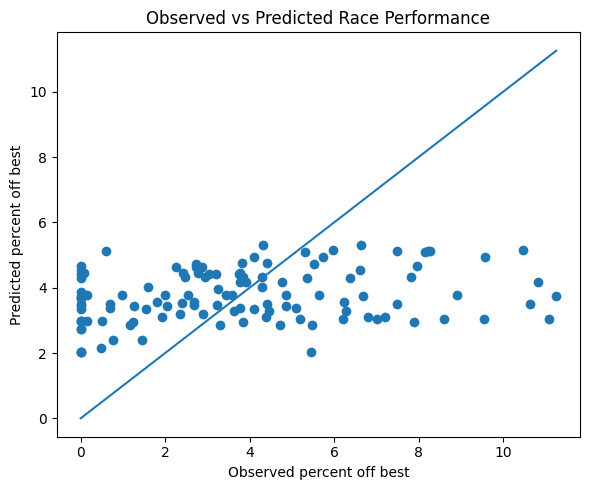

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

model_cols = [c for c in ["avg_pace_28d", "volume_28d", "volume_drop_ratio"] if c in race_df.columns]
model_data = race_df[model_cols + ["percent_off_best"]].dropna()

if len(model_data) >= len(model_cols) + 3:
    X = model_data[model_cols]
    y = model_data["percent_off_best"]
    model = LinearRegression().fit(X, y)
    pred = model.predict(X)
    print("Model coefficients:")
    for name, coef in zip(model_cols, model.coef_):
        print(f"  {name}: {coef:.5f}")
    print(f"Intercept: {model.intercept_:.3f}")
    print(f"R²: {r2_score(y, pred):.3f}")
    print(f"RMSE: {math.sqrt(mean_squared_error(y, pred)):.3f} percentage points")

    plt.figure(figsize=(6, 5))
    plt.scatter(y, pred)
    lims = [min(y.min(), pred.min()), max(y.max(), pred.max())]
    plt.plot(lims, lims)
    plt.title("Observed vs Predicted Race Performance")
    plt.xlabel("Observed percent off best")
    plt.ylabel("Predicted percent off best")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough race observations for a multi-variable model. Add more race results or reduce predictor count.")

## Save race-feature table

This table is the key output for correlations and modeling.

Data flow:

$$
\text{prepared workouts} + \text{prepared races} \rightarrow \text{race training features}
$$

Code-style implementation:

```python
race_df.to_csv(OUTPUT_DIR / "race_training_features.csv", index=False)
```

**Expected output:** Expect processed files or folders to be written for later notebooks and web-app views. The key interpretation is that downstream data is now prepared.


In [ ]:
race_df.to_csv(OUTPUT_DIR / "race_training_features.csv", index=False)
print("Saved:", OUTPUT_DIR / "race_training_features.csv")